In [91]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score, precision_score, recall_score


In [92]:
#Loading the dataset
data = pd.read_csv('updated_pollution_dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [93]:
#Create a copy of the data
data1 = data.copy(deep=True)

In [94]:
##Check the shape of the data
data1.shape

(5000, 10)

In [95]:
#Check missing values
data1.isnull().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

In [96]:
#Check for duplicates
duplicates = data1.duplicated().sum()
print(duplicates)

0


In [97]:
#Check the first 5 rows of the data
print(data1.head())

   Temperature  Humidity  PM2.5  PM10   NO2   SO2    CO  \
0         29.8      59.1    5.2  17.9  18.9   9.2  1.72   
1         28.3      75.6    2.3  12.2  30.8   9.7  1.64   
2         23.1      74.7   26.7  33.8  24.4  12.6  1.63   
3         27.1      39.1    6.1   6.3  13.5   5.3  1.15   
4         26.5      70.7    6.9  16.0  21.9   5.6  1.01   

   Proximity_to_Industrial_Areas  Population_Density Air Quality  
0                            6.3                 319    Moderate  
1                            6.0                 611    Moderate  
2                            5.2                 619    Moderate  
3                           11.1                 551        Good  
4                           12.7                 303        Good  


In [98]:
#%matplotlib inline
#Check the last 5 rows of the data
print(data1.tail())

      Temperature  Humidity  PM2.5   PM10   NO2   SO2    CO  \
4995         40.6      74.1  116.0  126.7  45.5  25.7  2.11   
4996         28.1      96.9    6.9   25.0  25.3  10.8  1.54   
4997         25.9      78.2   14.2   22.1  34.8   7.8  1.63   
4998         25.3      44.4   21.4   29.0  23.7   5.7  0.89   
4999         24.1      77.9   81.7   94.3  23.2  10.5  1.38   

      Proximity_to_Industrial_Areas  Population_Density Air Quality  
4995                            2.8                 765   Hazardous  
4996                            5.7                 709    Moderate  
4997                            9.6                 379    Moderate  
4998                           11.6                 241        Good  
4999                            8.3                 461    Moderate  


In [99]:
#Check the column names
print(data1.columns)

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality'],
      dtype='object')


In [100]:
#Check the data types of the columns
print(data1.dtypes)

Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density                 int64
Air Quality                       object
dtype: object


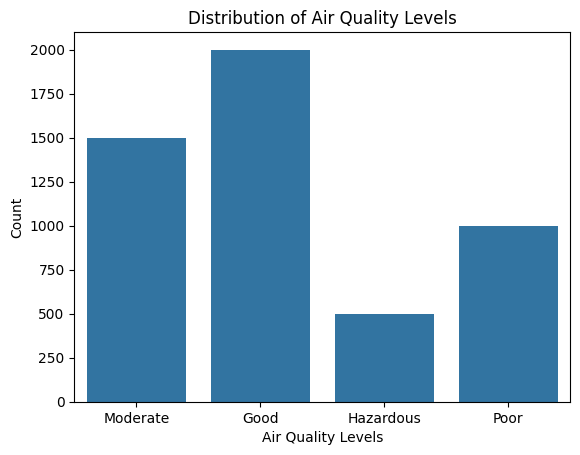

In [101]:
#EDA
#Check the distribution of the target variable
sns.countplot(x='Air Quality', data=data1)
plt.title('Distribution of Air Quality Levels')
plt.xlabel('Air Quality Levels')
plt.ylabel('Count')
plt.show()

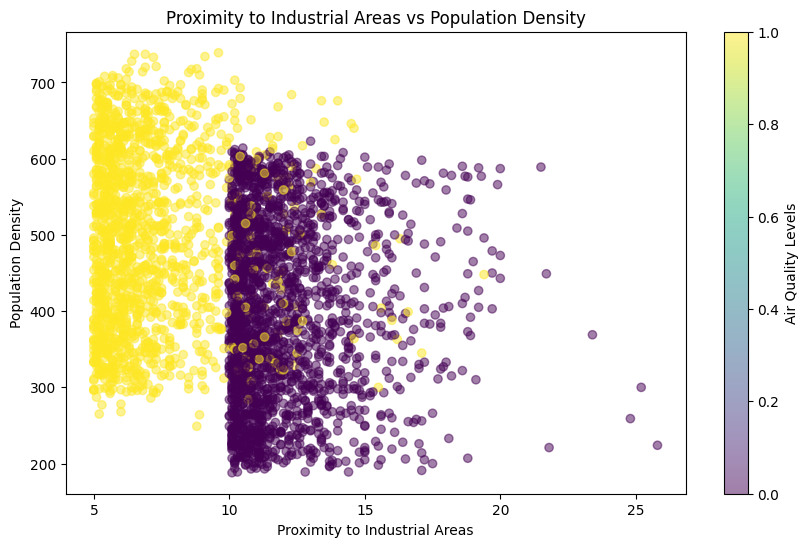

In [102]:
#Scatter plot for Proximity_to_Industrial_Areas column and Population_Density
plt.figure(figsize=(10, 6))
plt.scatter(data1['Proximity_to_Industrial_Areas'], data1['Population_Density'], c=data1['Air Quality'].map({'Good': 0, 'Moderate': 1, 'Unhealthy': 2}), cmap='viridis', alpha=0.5)
plt.colorbar(label='Air Quality Levels')
plt.title('Proximity to Industrial Areas vs Population Density')
plt.xlabel('Proximity to Industrial Areas')
plt.ylabel('Population Density')
plt.show()


In [103]:
#Split the data into features and target variable
X = data1.drop('Air Quality', axis=1)
y = data1['Air Quality']
print(X)

      Temperature  Humidity  PM2.5   PM10   NO2   SO2    CO  \
0            29.8      59.1    5.2   17.9  18.9   9.2  1.72   
1            28.3      75.6    2.3   12.2  30.8   9.7  1.64   
2            23.1      74.7   26.7   33.8  24.4  12.6  1.63   
3            27.1      39.1    6.1    6.3  13.5   5.3  1.15   
4            26.5      70.7    6.9   16.0  21.9   5.6  1.01   
...           ...       ...    ...    ...   ...   ...   ...   
4995         40.6      74.1  116.0  126.7  45.5  25.7  2.11   
4996         28.1      96.9    6.9   25.0  25.3  10.8  1.54   
4997         25.9      78.2   14.2   22.1  34.8   7.8  1.63   
4998         25.3      44.4   21.4   29.0  23.7   5.7  0.89   
4999         24.1      77.9   81.7   94.3  23.2  10.5  1.38   

      Proximity_to_Industrial_Areas  Population_Density  
0                               6.3                 319  
1                               6.0                 611  
2                               5.2                 619  
3          

In [104]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
#Check the shape of the training and testing sets
print(X_train.shape)
print(X_test.shape)

(4000, 9)
(1000, 9)


In [106]:
#Transform the data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [107]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Check the shape of the training and testing sets
print(X_train.shape)
print(X_test.shape)
#Transform the data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



(4000, 9)
(1000, 9)


In [108]:
#Train the model using Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [109]:
#Make predictions on the test set
y_pred = rf.predict(X_test)
#Check the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.96


In [110]:
#Check the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       409
   Hazardous       0.92      0.88      0.90       111
    Moderate       0.97      0.97      0.97       294
        Poor       0.88      0.90      0.89       186

    accuracy                           0.96      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000



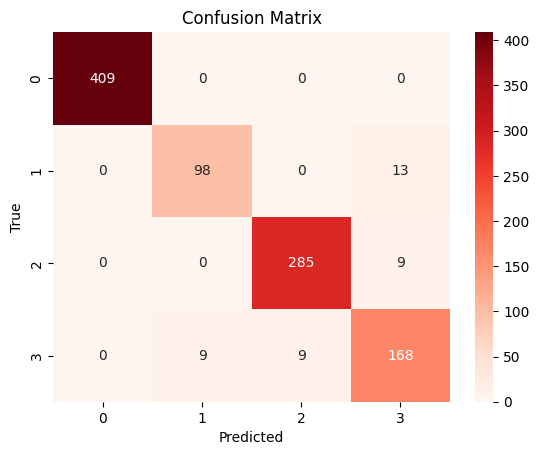

In [111]:
#Check the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [112]:
#Check the first 5 predictions
print(predictions[:5])

['Hazardous' 'Good' 'Moderate' 'Hazardous' 'Good']


In [113]:
#Check the feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
# Print the feature ranking
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{f + 1}. feature {X.columns[indices[f]]} ({importances[indices[f]]})")
    

Feature ranking:
1. feature CO (0.33467840428684115)
2. feature Proximity_to_Industrial_Areas (0.2877121053396791)
3. feature NO2 (0.09914158538080776)
4. feature SO2 (0.0925866313563424)
5. feature Temperature (0.07377636101675193)
6. feature Population_Density (0.04192894939086153)
7. feature Humidity (0.034425860529136654)
8. feature PM10 (0.022763311300666826)
9. feature PM2.5 (0.012986791398912765)


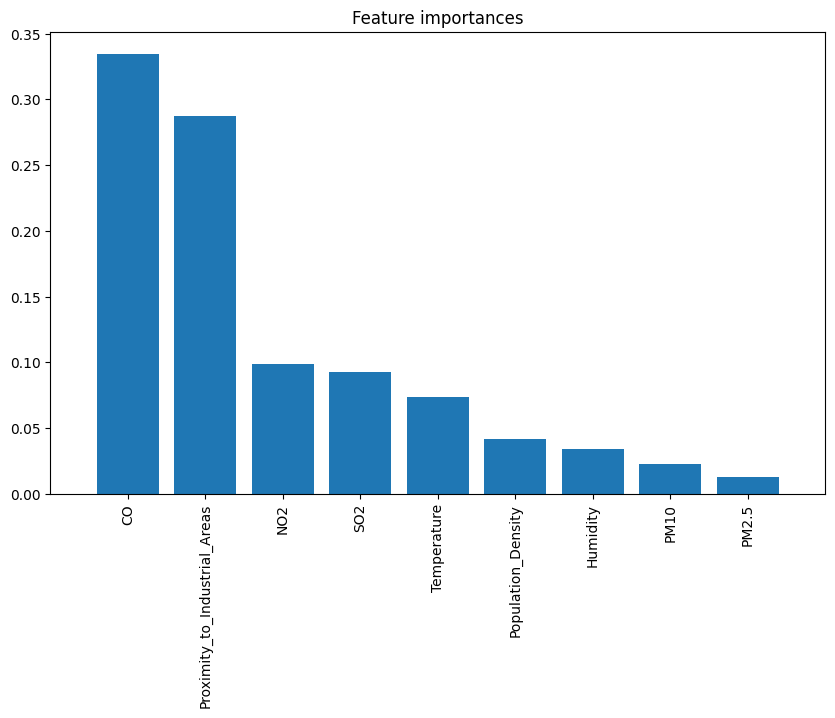

In [114]:
#Explore the feature importance using a bar plot
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

In [115]:
#Test the model on new data
# Assuming new_data is a DataFrame with the same features as X_test
new_data = pd.DataFrame({
    'Temperature': [25, 30],
    'Humidity': [60, 110],
    'PM2.5': [35, 40],
    'PM10': [50, 55],
    'NO2': [20, 5],
    'SO2': [5, 10],
    'CO': [0.5, 0.6],
    'Proximity_to_Industrial_Areas': [1, 0],
    'Population_Density': [1000, 2000],
})
# Transform the new data using the same scaler
new_data_scaled = scaler.transform(new_data)
# Make predictions on the new data
predictions_new = rf.predict(new_data_scaled)
# Print the predictions
print(predictions_new)
print("The model is trained and tested sucessfully!")


['Moderate' 'Hazardous']
The model is trained and tested sucessfully!


In [116]:
#Conclusion
#The model has been trained and tested successfully. 
#The accuracy of the model is 0.96. 
